In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
RUNS = {
    "curv=0": Path("/scratch/shelvia.wongso/cbo_results/ucbo_slow_runs_denomfloor_1e-8/cifar100_resnet20/lr_0.2_wd_2e-4_h0_0.5_curv_0.0"),
    "curv=4e-6": Path("/scratch/shelvia.wongso/cbo_results/ucbo_slow_runs_denomfloor_1e-8/cifar100_resnet20/lr_0.2_wd_2e-4_h0_0.5_curv_4e-6"),
}
SEEDS = list(range(5))

In [36]:
def find_single_run_dir(seed_dir: Path) -> Path:
    if not seed_dir.exists():
        raise FileNotFoundError(f"Missing seed directory: {seed_dir}")

    subdirs = [p for p in seed_dir.iterdir() if p.is_dir()]
    if len(subdirs) != 1:
        raise ValueError(f"Expected exactly 1 timestamp folder in {seed_dir}, found {len(subdirs)}: {subdirs}")
    return subdirs[0]

def read_one_csv(run_root: Path, seed: int, filename: str) -> pd.DataFrame:
    seed_dir = run_root / f"seed={seed}"
    run_dir = find_single_run_dir(seed_dir)
    csv_path = run_dir / filename
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing file: {csv_path}")

    df = pd.read_csv(csv_path)

    if "epoch" not in df.columns:
        raise ValueError(f"{csv_path} has no 'epoch' column. Columns: {list(df.columns)}")

    df = df.copy()
    df["epoch"] = df["epoch"].astype(int)
    df = df.sort_values("epoch")

    df = df.groupby("epoch", as_index=False).last()
    return df

def read_csv_for_seeds(run_root: Path, filename: str, seeds=SEEDS) -> list[pd.DataFrame]:
    dfs = []
    missing = []
    for s in seeds:
        try:
            dfs.append(read_one_csv(run_root, s, filename))
        except Exception as e:
            missing.append((s, str(e)))

    if missing:
        print(f"[WARN] Issues reading {filename} under {run_root}:")
        for s, msg in missing:
            print(f"  seed={s}: {msg}")

    if len(dfs) == 0:
        raise FileNotFoundError(f"Could not read any {filename} for seeds {seeds} under {run_root}")
    return dfs

def stack_metric_by_epoch(dfs: list[pd.DataFrame], metric: str) -> pd.DataFrame:
    cols = set(dfs[0].columns)
    if metric not in cols:
        raise ValueError(f"Metric '{metric}' not found. Available: {sorted(cols)}")

    wide = None
    for i, df in enumerate(dfs):
        tmp = df[["epoch", metric]].rename(columns={metric: f"seed{i}"}).set_index("epoch")
        wide = tmp if wide is None else wide.join(tmp, how="outer")
    return wide.sort_index()

def summarize_minmax_mean(wide: pd.DataFrame) -> pd.DataFrame:
    arr = wide.to_numpy(dtype=float)
    return pd.DataFrame(
        {
            "mean": np.nanmean(arr, axis=1),
            "min":  np.nanmin(arr, axis=1),
            "max":  np.nanmax(arr, axis=1),
        },
        index=wide.index,
    )

def plot_metric(ax, filename: str, metric: str, title: str, ylab: str, is_accuracy=False):
    for run_label, run_root in RUNS.items():
        dfs = read_csv_for_seeds(run_root, filename)
        wide = stack_metric_by_epoch(dfs, metric)
        stats = summarize_minmax_mean(wide)

        epochs = stats.index.values
        ax.plot(epochs, stats["mean"].values, label=run_label)
        ax.fill_between(epochs, stats["min"].values, stats["max"].values, alpha=0.2)

    ax.set_title(title)
    ax.set_xlabel("Epoch", fontsize=11)
    ax.set_ylabel(ylab, fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend()
    if is_accuracy:
        ax.set_ylim(0.0, 1.0)


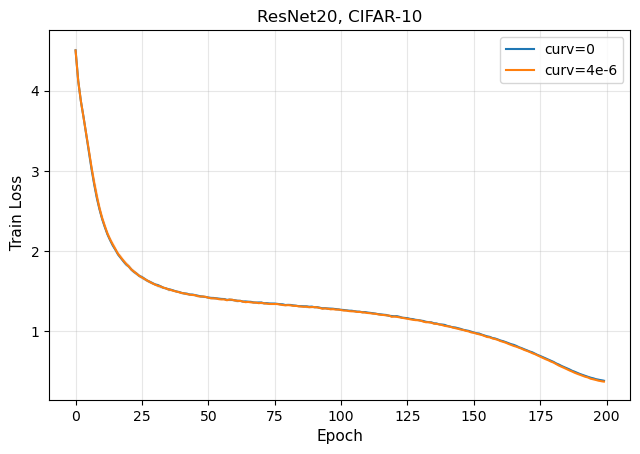

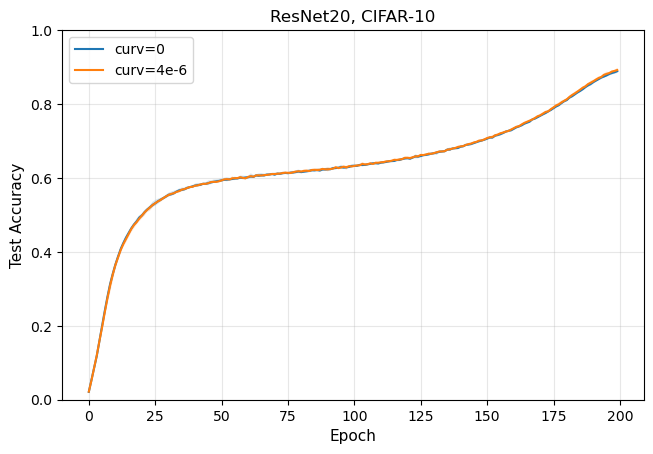

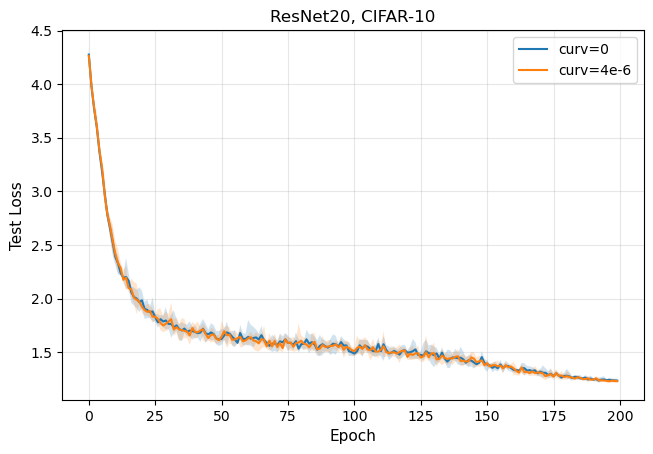

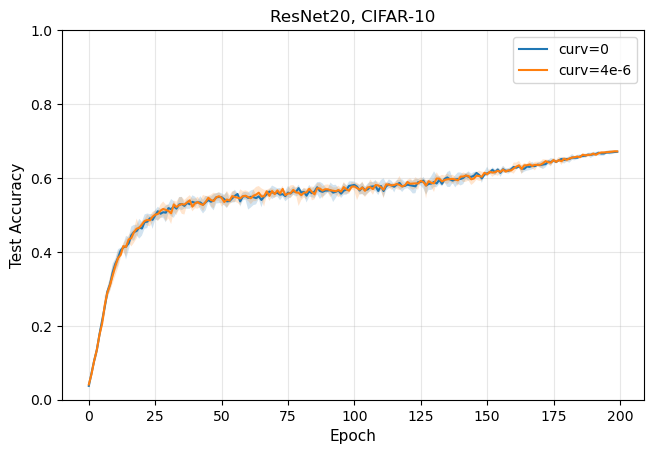

In [37]:
# Train loss
fig, ax = plt.subplots(figsize=(7.5, 4.8))
plot_metric(ax, "train.csv", "loss", "ResNet20, CIFAR-10", " Train Loss")
plt.show()

# Train accuracy
fig, ax = plt.subplots(figsize=(7.5, 4.8))
plot_metric(ax, "train.csv", "acc", "ResNet20, CIFAR-10", "Test Accuracy", is_accuracy=True)
plt.show()

# Test loss
fig, ax = plt.subplots(figsize=(7.5, 4.8))
plot_metric(ax, "test.csv", "loss", "ResNet20, CIFAR-10", "Test Loss")
plt.show()

# Test accuracy
fig, ax = plt.subplots(figsize=(7.5, 4.8))
plot_metric(ax, "test.csv", "acc", "ResNet20, CIFAR-10", "Test Accuracy", is_accuracy=True)
plt.show()


In [38]:
def plot_metric_zoom(ax, filename: str, metric: str, title: str, ylab: str,
                     zoom_last=20, pad_frac=0.05, is_accuracy=False):
    all_stats = []
    for run_label, run_root in RUNS.items():
        dfs = read_csv_for_seeds(run_root, filename)
        wide = stack_metric_by_epoch(dfs, metric)
        stats = summarize_minmax_mean(wide)
        all_stats.append(stats)

        epochs = stats.index.values
        ax.plot(epochs, stats["mean"].values, label=run_label)
        ax.fill_between(epochs, stats["min"].values, stats["max"].values, alpha=0.2)

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylab)
    ax.grid(True, alpha=0.3)
    ax.legend()

    common_epochs = all_stats[0].index
    for st in all_stats[1:]:
        common_epochs = common_epochs.intersection(st.index)

    if len(common_epochs) > 0:
        zoom_epochs = common_epochs[-zoom_last:] if len(common_epochs) >= zoom_last else common_epochs
        x0, x1 = int(zoom_epochs[0]), int(zoom_epochs[-1])
        ax.set_xlim(x0, x1)

        ymins = [st.loc[zoom_epochs, "min"].min() for st in all_stats]
        ymaxs = [st.loc[zoom_epochs, "max"].max() for st in all_stats]
        y0, y1 = float(min(ymins)), float(max(ymaxs))
        pad = (y1 - y0) * pad_frac if y1 > y0 else (0.01 if is_accuracy else 1e-3)
        ax.set_ylim(y0 - pad, y1 + pad)

    if is_accuracy:
        pass

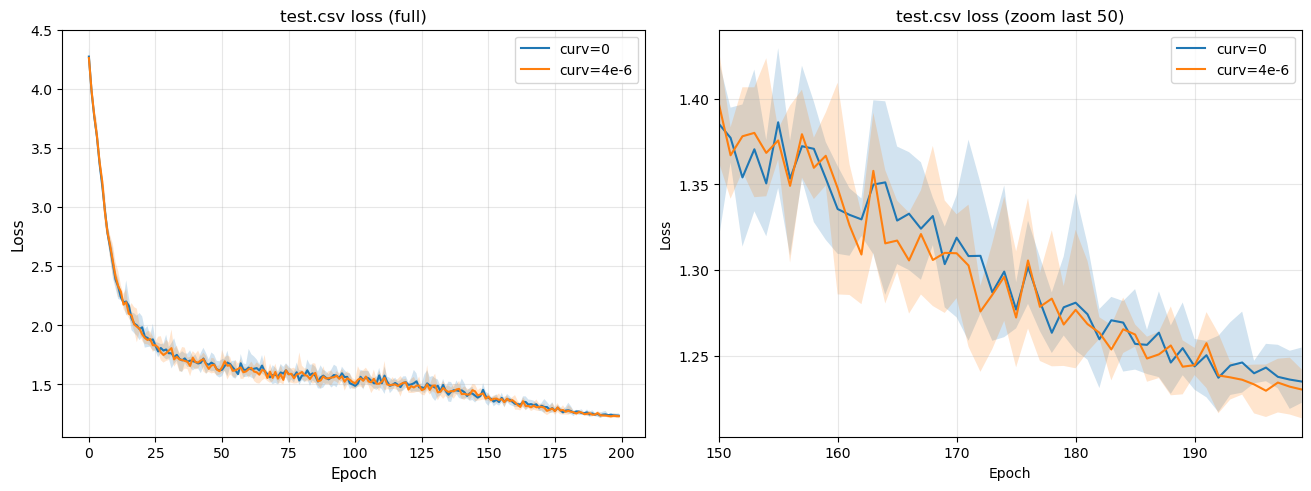

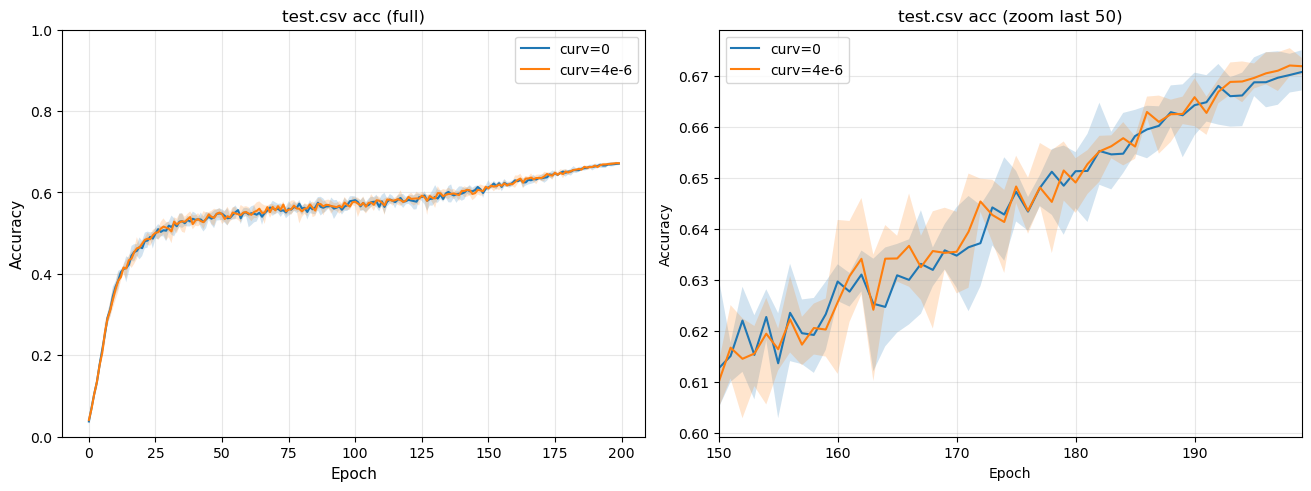

In [40]:
def plot_full_and_zoom(filename, metric, ylab, is_accuracy=False, zoom_last=20):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

    plot_metric(ax1, filename, metric, f"{filename} {metric} (full)", ylab, is_accuracy=is_accuracy)

    plot_metric_zoom(ax2, filename, metric, f"{filename} {metric} (zoom last {zoom_last})", ylab,
                     zoom_last=zoom_last, is_accuracy=is_accuracy)

    plt.show()

plot_full_and_zoom("test.csv", "loss", "Test Loss", zoom_last=50)
plot_full_and_zoom("test.csv", "acc", "Test Accuracy", is_accuracy=True, zoom_last=50)
